# LSTM vs Transformer for Stock Price Time Series Prediction (PyTorch)

In this Lab, we compare two neural architectures on the same time-series prediction task:

1. **LSTM baseline**
2. **Transformer Encoder model**

The task is:

> Use the last `LOOKBACK` stock prices to predict the next `HORIZON` stock prices.

By default:

- `LOOKBACK = 5`
- `HORIZON = 5`
- data source: Yahoo Finance via `yfinance`
- target variable: adjusted close price, or close price if adjusted close is unavailable

## 1. Install dependencies

Run this cell in Colab or a fresh environment.

In [1]:
# If you already have these packages, this cell can be skipped.
%pip install -q yfinance scikit-learn

## 2. Imports and configuration

In [2]:
import os
import random
import time
import math
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Main experiment settings
TICKER = "AAPL"
START_DATE = "2014-01-01"
END_DATE = None          # None = today
LOOKBACK = 5              # number of past days used as input
HORIZON = 5               # number of future days predicted
TRAIN_RATIO = 0.8

EPOCHS = 25
BATCH_SIZE = 32

PyTorch version: 2.11.0+cu128
Using device: cuda


## 3. Load stock price data

We download historical stock prices from Yahoo Finance.

The notebook uses `Adj Close` when available, otherwise `Close`.

In [3]:
def load_stock_data(ticker, start_date, end_date=None):
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False, progress=False)

    if df.empty:
        raise ValueError(f"No data found for ticker: {ticker}")

    # yfinance can return multi-index columns in some versions.
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    price_col = "Adj Close" if "Adj Close" in df.columns else "Close"
    df = df[[price_col]].dropna()
    df = df.rename(columns={price_col: "price"})
    return df

df = load_stock_data(TICKER, START_DATE, END_DATE)
df.head(), df.tail(), df.shape

(                price
 Date                 
 2014-01-02  17.110132
 2014-01-03  16.734291
 2014-01-06  16.825541
 2014-01-07  16.705206
 2014-01-08  16.811005,
                  price
 Date                  
 2026-09-08  316.220001
 2026-09-09  315.339996
 2026-09-10  326.570007
 2026-09-11  332.269989
 2026-09-14  333.079987,
 (3193, 1))

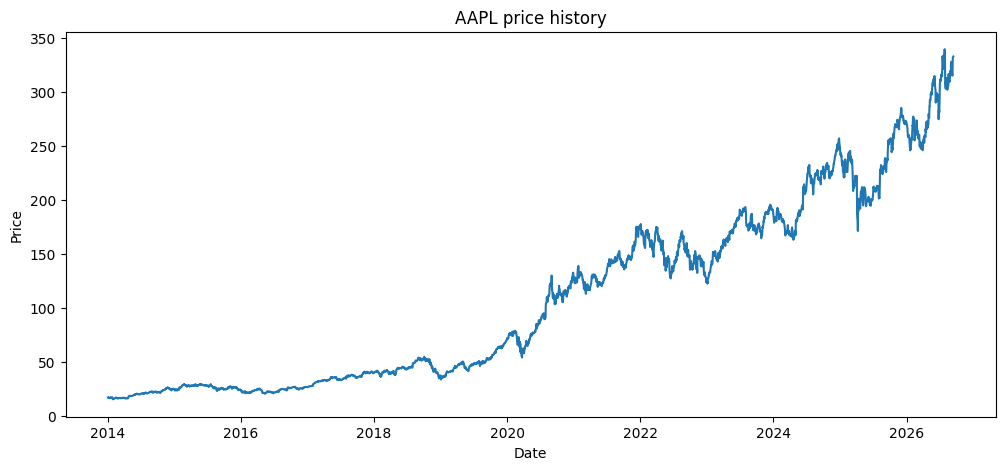

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["price"])
plt.title(f"{TICKER} price history")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## 4. Create supervised learning windows

For each sample:

- `X`: previous `LOOKBACK` prices
- `y`: next `HORIZON` prices

Example with `LOOKBACK = 5` and `HORIZON = 5`:

```text
X = [day 1, day 2, day 3, day 4, day 5]
y = [day 6, day 7, day 8, day 9, day 10]
```

In [5]:
def make_windows(series, lookback=5, horizon=5):
    X, y = [], []
    values = np.asarray(series).reshape(-1)

    for i in range(len(values) - lookback - horizon + 1):
        X.append(values[i : i + lookback])
        y.append(values[i + lookback : i + lookback + horizon])

    X = np.array(X, dtype="float32")
    y = np.array(y, dtype="float32")

    # PyTorch sequence models expect the same shape as Keras: (samples, timesteps, features)
    X = X[..., np.newaxis]
    return X, y

# Chronological split before scaling to avoid leakage
prices = df["price"].values.reshape(-1, 1)
split_index = int(len(prices) * TRAIN_RATIO)

train_prices = prices[:split_index]
test_prices = prices[split_index - LOOKBACK - HORIZON + 1:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_prices).reshape(-1)
test_scaled = scaler.transform(test_prices).reshape(-1)

X_train, y_train = make_windows(train_scaled, LOOKBACK, HORIZON)
X_test, y_test = make_windows(test_scaled, LOOKBACK, HORIZON)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (2545, 5, 1)
y_train: (2545, 5)
X_test: (639, 5, 1)
y_test: (639, 5)


## 5. Metrics and helper functions

**PyTorch note:** the original `plot_history` reads from a Keras `History` object (`history.history["loss"]`). Since PyTorch has no built-in `.fit()`, we'll instead build a plain dictionary with the same keys (`"loss"`, `"val_loss"`) ourselves inside the training loop below, so `plot_history` can stay almost unchanged.

In [6]:
def inverse_scale_targets(y_scaled, scaler):
    # y_scaled shape: (samples, horizon)
    flat = y_scaled.reshape(-1, 1)
    inv = scaler.inverse_transform(flat)
    return inv.reshape(y_scaled.shape)

def regression_metrics(y_true_scaled, y_pred_scaled, scaler):
    y_true = inverse_scale_targets(y_true_scaled, scaler)
    y_pred = inverse_scale_targets(y_pred_scaled, scaler)

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    }

def plot_history(history, title):
    plt.figure(figsize=(10, 4))
    plt.plot(history["loss"], label="train loss")
    plt.plot(history["val_loss"], label="val loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.show()

def plot_predictions(y_true_scaled, y_pred_scaled, scaler, title, horizon_step=0, max_points=200):
    y_true = inverse_scale_targets(y_true_scaled, scaler)
    y_pred = inverse_scale_targets(y_pred_scaled, scaler)

    n = min(max_points, len(y_true))

    plt.figure(figsize=(12, 5))
    plt.plot(y_true[:n, horizon_step], label="true")
    plt.plot(y_pred[:n, horizon_step], label="predicted")
    plt.title(f"{title} - prediction for horizon day {horizon_step + 1}")
    plt.xlabel("Test sample")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

**Training utilities:** PyTorch has no `EarlyStopping` callback, so we implement it manually (same behavior as Keras's `EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)`): track the best validation loss, keep a deep copy of the best weights, stop once `patience` epochs pass without improvement, then reload the best weights.

We write **one** shared training function and reuse it for both models below (the original notebook duplicated the training loop for each model via two separate `.fit()` calls).

In [7]:
def evaluate_regressor(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            total_loss += loss.item() * xb.size(0)
            total += xb.size(0)
    return total_loss / total


def train_with_early_stopping(model, train_loader, val_loader, device, epochs=25, patience=8, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            total += xb.size(0)

        train_loss = running_loss / total
        val_loss = evaluate_regressor(model, val_loader, criterion, device)

        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.6f} - val_loss: {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered after epoch {epoch+1}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)  # restore_best_weights=True equivalent

    return history


def predict(model, X, device, batch_size=256):
    model.eval()
    loader = DataLoader(TensorDataset(torch.tensor(X)), batch_size=batch_size, shuffle=False)
    preds = []
    with torch.no_grad():
        for (xb,) in loader:
            preds.append(model(xb.to(device)).cpu().numpy())
    return np.concatenate(preds, axis=0)


def count_params(model):
    return sum(p.numel() for p in model.parameters())

In [8]:
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)  # also used as the validation set, like in the original notebook

## 6. Model 1: LSTM baseline

This is the recurrent baseline.

It processes the sequence step by step and uses its hidden state to summarize recent price history.

In [9]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, horizon, hidden_size=200, dense_dim=50):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size, batch_first=True)
        self.dense1 = nn.Linear(hidden_size, dense_dim)
        self.dense2 = nn.Linear(dense_dim, horizon)

    def forward(self, x):
        # x: (batch, lookback, n_features)
        out, _ = self.lstm(x)          # (batch, lookback, hidden_size) - full sequence
        out = out[:, -1, :]             # keep the last time step only, like Keras's default LSTM(return_sequences=False)
        out = torch.relu(self.dense1(out))
        return self.dense2(out)         # raw regression output, no final activation


lstm_model = LSTMRegressor(n_features=1, horizon=HORIZON).to(device)
print(lstm_model)
print(f"Total parameters: {count_params(lstm_model):,}")

LSTMRegressor(
  (lstm): LSTM(1, 200, batch_first=True)
  (dense1): Linear(in_features=200, out_features=50, bias=True)
  (dense2): Linear(in_features=50, out_features=5, bias=True)
)
Total parameters: 172,705


In [10]:
start_time = time.time()

lstm_history = train_with_early_stopping(lstm_model, train_loader, test_loader, device,
                                          epochs=EPOCHS, patience=8, lr=1e-3)

lstm_train_time = time.time() - start_time
print(f"LSTM training time: {lstm_train_time:.2f} seconds")

Epoch 1/25 - loss: 0.048064 - val_loss: 0.043762
Epoch 2/25 - loss: 0.001075 - val_loss: 0.005097
Epoch 3/25 - loss: 0.000515 - val_loss: 0.007834
Epoch 4/25 - loss: 0.000496 - val_loss: 0.010659
Epoch 5/25 - loss: 0.000445 - val_loss: 0.008002
Epoch 6/25 - loss: 0.000454 - val_loss: 0.009111
Epoch 7/25 - loss: 0.000458 - val_loss: 0.012255
Epoch 8/25 - loss: 0.000470 - val_loss: 0.011943
Epoch 9/25 - loss: 0.000438 - val_loss: 0.007457
Epoch 10/25 - loss: 0.000436 - val_loss: 0.006002
Early stopping triggered after epoch 10.
LSTM training time: 14.88 seconds


LSTM metrics:
MAE: 9.5747
RMSE: 12.8696
MAPE (%): 3.8852


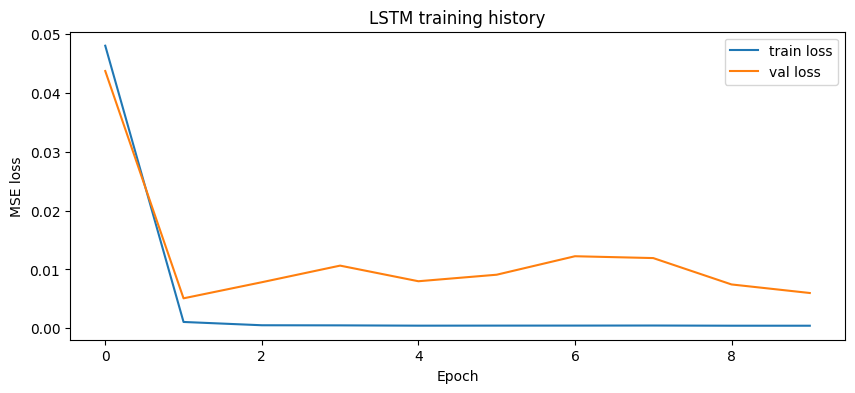

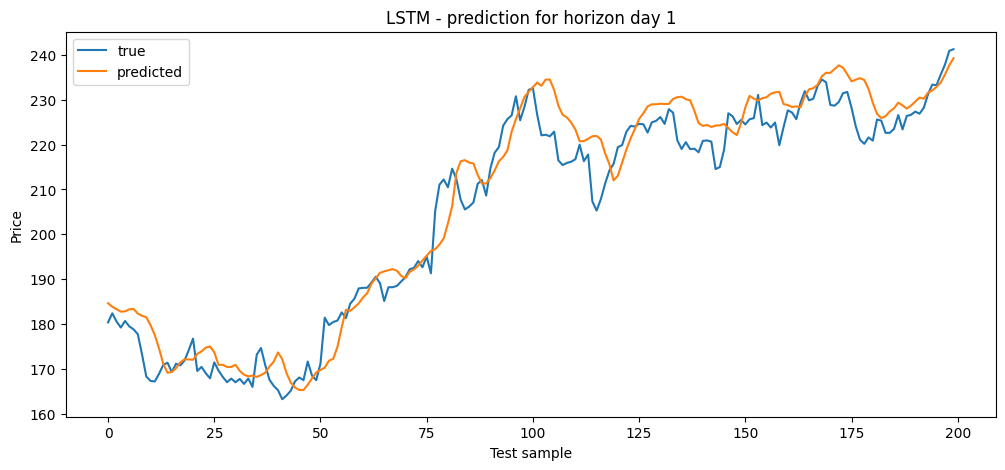

In [11]:
lstm_pred = predict(lstm_model, X_test, device)
lstm_metrics = regression_metrics(y_test, lstm_pred, scaler)

print("LSTM metrics:")
for k, v in lstm_metrics.items():
    print(f"{k}: {v:.4f}")

plot_history(lstm_history, "LSTM training history")
plot_predictions(y_test, lstm_pred, scaler, "LSTM")

## 7. Model 2: Transformer Encoder

The Transformer does not use recurrence.

Instead, it uses **self-attention** to compare each timestep with other timesteps in the input window.

**Important PyTorch adaptation note:** Keras's `layers.MultiHeadAttention(key_dim=32, num_heads=4)` is more flexible than PyTorch's `nn.MultiheadAttention`. Keras lets the *internal* attention dimension (`key_dim x num_heads = 128` here) be completely independent from the input's actual feature dimension (`n_features = 1`, since we only have the price as input) — it silently adds its own Dense projections up to `key_dim x num_heads` for queries/keys/values, and a final projection back down to the input's feature size for the residual connection. PyTorch's `nn.MultiheadAttention` instead requires `embed_dim` (the input size) to be **exactly** the attention dimension, split evenly across heads — it can't project a 1-dimensional input up to a 128-dimensional attention space internally.

To reproduce Keras's behavior exactly, we implement a small custom multi-head self-attention module with its own Q/K/V projections (up to `head_size x num_heads`) and an output projection back down to the input dimension, instead of using `nn.MultiheadAttention` directly.

In [12]:
class MultiHeadSelfAttention(nn.Module):
    # Custom multi-head self-attention that supports an internal attention
    # dimension (head_size * num_heads) independent from the input's feature
    # dimension -- matching Keras's layers.MultiHeadAttention(key_dim=...) behavior.
    def __init__(self, input_dim, head_size, num_heads, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_size = head_size
        inner_dim = head_size * num_heads

        self.q_proj = nn.Linear(input_dim, inner_dim)
        self.k_proj = nn.Linear(input_dim, inner_dim)
        self.v_proj = nn.Linear(input_dim, inner_dim)
        self.out_proj = nn.Linear(inner_dim, input_dim)  # project back down to input_dim, for the residual connection
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        b, t, _ = x.shape

        q = self.q_proj(x).view(b, t, self.num_heads, self.head_size).transpose(1, 2)  # (b, heads, t, head_size)
        k = self.k_proj(x).view(b, t, self.num_heads, self.head_size).transpose(1, 2)
        v = self.v_proj(x).view(b, t, self.num_heads, self.head_size).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_size)  # (b, heads, t, t)
        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context = torch.matmul(attn_weights, v)                                     # (b, heads, t, head_size)
        context = context.transpose(1, 2).contiguous().view(b, t, self.num_heads * self.head_size)
        return self.out_proj(context)                                               # (b, t, input_dim)

In [13]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, input_dim, head_size, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        # Self-attention block
        self.norm1 = nn.LayerNorm(input_dim, eps=1e-6)
        self.attn = MultiHeadSelfAttention(input_dim, head_size, num_heads, dropout)
        self.dropout1 = nn.Dropout(dropout)

        # Feed-forward block: Keras uses Conv1D(kernel_size=1), the exact equivalent of a
        # position-wise Linear layer applied independently to every timestep
        self.norm2 = nn.LayerNorm(input_dim, eps=1e-6)
        self.ff1 = nn.Conv1d(input_dim, ff_dim, kernel_size=1)
        self.ff2 = nn.Conv1d(ff_dim, input_dim, kernel_size=1)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        attn_out = self.attn(self.norm1(x))
        attn_out = self.dropout1(attn_out)
        x = x + attn_out  # residual 1

        ff_in = self.norm2(x).transpose(1, 2)     # (batch, input_dim, seq_len) for Conv1d
        ff = torch.relu(self.ff1(ff_in))
        ff = self.dropout2(ff)
        ff = self.ff2(ff).transpose(1, 2)          # back to (batch, seq_len, input_dim)

        return x + ff  # residual 2


class TransformerRegressor(nn.Module):
    def __init__(self, n_features, horizon, head_size=32, num_heads=4, ff_dim=32,
                 num_transformer_blocks=4, mlp_units=(128,), dropout=0.1, mlp_dropout=0.1):
        super().__init__()
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(n_features, head_size, num_heads, ff_dim, dropout)
            for _ in range(num_transformer_blocks)
        ])

        mlp_layers = []
        in_dim = n_features
        for units in mlp_units:
            mlp_layers += [nn.Linear(in_dim, units), nn.ReLU(), nn.Dropout(mlp_dropout)]
            in_dim = units
        self.mlp = nn.Sequential(*mlp_layers)

        self.output_layer = nn.Linear(in_dim, horizon)

    def forward(self, x):
        # x: (batch, lookback, n_features)
        for block in self.blocks:
            x = block(x)
        x = x.mean(dim=1)  # GlobalAveragePooling1D equivalent: average over the time dimension
        x = self.mlp(x)
        return self.output_layer(x)


transformer_model = TransformerRegressor(
    n_features=1,
    horizon=HORIZON,
    head_size=32,
    num_heads=4,
    ff_dim=32,
    num_transformer_blocks=4,
    mlp_units=(128,),
    dropout=0.1,
    mlp_dropout=0.1
).to(device)

print(transformer_model)
print(f"Total parameters: {count_params(transformer_model):,}")

TransformerRegressor(
  (blocks): ModuleList(
    (0-3): 4 x TransformerEncoderBlock(
      (norm1): LayerNorm((1,), eps=1e-06, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (q_proj): Linear(in_features=1, out_features=128, bias=True)
        (k_proj): Linear(in_features=1, out_features=128, bias=True)
        (v_proj): Linear(in_features=1, out_features=128, bias=True)
        (out_proj): Linear(in_features=128, out_features=1, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout1): Dropout(p=0.1, inplace=False)
      (norm2): LayerNorm((1,), eps=1e-06, elementwise_affine=True)
      (ff1): Conv1d(1, 32, kernel_size=(1,), stride=(1,))
      (ff2): Conv1d(32, 1, kernel_size=(1,), stride=(1,))
      (dropout2): Dropout(p=0.1, inplace=False)
    )
  )
  (mlp): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
  )
  (output_layer): Linear(in_features=128, out

In [14]:
start_time = time.time()

transformer_history = train_with_early_stopping(transformer_model, train_loader, test_loader, device,
                                                  epochs=EPOCHS, patience=8, lr=1e-3)

transformer_train_time = time.time() - start_time
print(f"Transformer training time: {transformer_train_time:.2f} seconds")

Epoch 1/25 - loss: 0.043365 - val_loss: 0.028476
Epoch 2/25 - loss: 0.016976 - val_loss: 0.010409
Epoch 3/25 - loss: 0.013065 - val_loss: 0.004238
Epoch 4/25 - loss: 0.010750 - val_loss: 0.004404
Epoch 5/25 - loss: 0.008495 - val_loss: 0.007038
Epoch 6/25 - loss: 0.007716 - val_loss: 0.006578
Epoch 7/25 - loss: 0.006144 - val_loss: 0.014135
Epoch 8/25 - loss: 0.005976 - val_loss: 0.006570
Epoch 9/25 - loss: 0.004947 - val_loss: 0.009151
Epoch 10/25 - loss: 0.004733 - val_loss: 0.008780
Epoch 11/25 - loss: 0.004094 - val_loss: 0.017277
Early stopping triggered after epoch 11.
Transformer training time: 13.22 seconds


Transformer metrics:
MAE: 8.8728
RMSE: 11.7355
MAPE (%): 3.7112


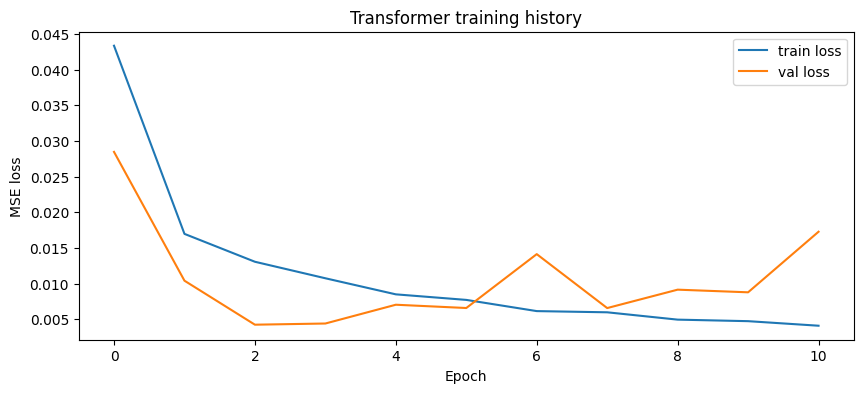

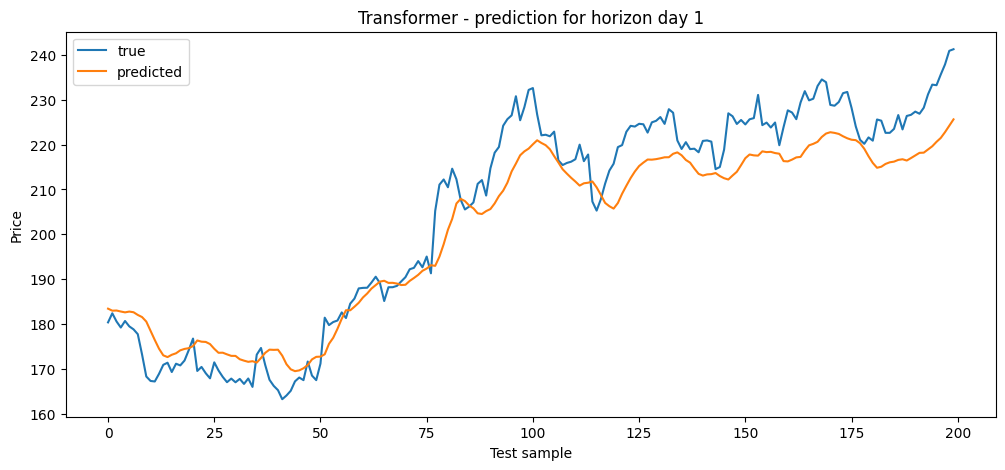

In [15]:
transformer_pred = predict(transformer_model, X_test, device)
transformer_metrics = regression_metrics(y_test, transformer_pred, scaler)

print("Transformer metrics:")
for k, v in transformer_metrics.items():
    print(f"{k}: {v:.4f}")

plot_history(transformer_history, "Transformer training history")
plot_predictions(y_test, transformer_pred, scaler, "Transformer")

## 8. Compare results

This section compares:

- model size
- training time
- MAE
- RMSE
- MAPE

In [16]:
comparison = pd.DataFrame([
    {
        "Model": "LSTM",
        "Parameters": count_params(lstm_model),
        "Training time (s)": lstm_train_time,
        **lstm_metrics
    },
    {
        "Model": "Transformer",
        "Parameters": count_params(transformer_model),
        "Training time (s)": transformer_train_time,
        **transformer_metrics
    }
])

comparison

,Model,Parameters,Training time (s),MAE,RMSE,MAPE (%)
0,LSTM,172705,14.883182,9.574744,12.869617,3.885228
1,Transformer,4893,13.224299,8.872818,11.735506,3.711228


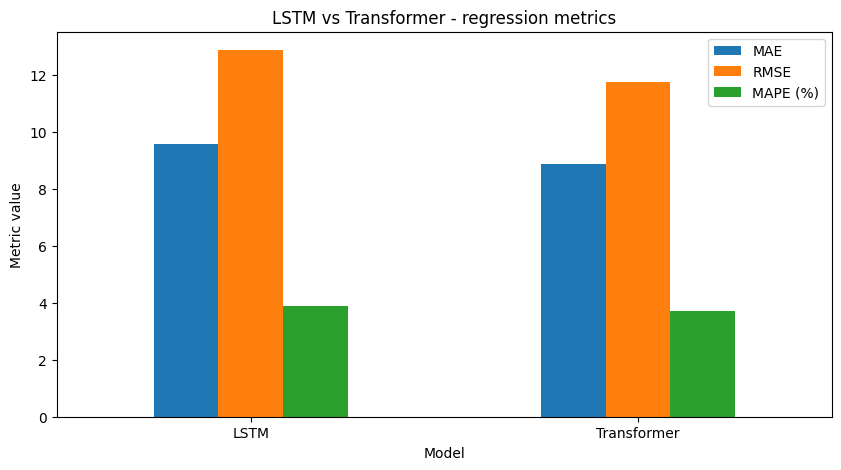

In [17]:
ax = comparison.set_index("Model")[["MAE", "RMSE", "MAPE (%)"]].plot(
    kind="bar",
    figsize=(10, 5),
    rot=0
)
plt.title("LSTM vs Transformer - regression metrics")
plt.ylabel("Metric value")
plt.show()

### Exercise 5: Naive Baseline Comparison

A naive baseline predicts that the next $H$ future values are exactly equal to the last observed value in the input sequence. Let's build and evaluate this baseline.

In [18]:
# Naive prediction: repeat the last price of lookback for the entire horizon
# X_test shape: (samples, lookback, 1)
# The last observed value is at index -1 along the lookback dimension
last_observed_scaled = X_test[:, -1, 0]  # shape: (samples,)

# Broadcast this single price across the HORIZON dimension
naive_pred_scaled = np.repeat(last_observed_scaled[:, np.newaxis], HORIZON, axis=1)

# Compute regression metrics
naive_metrics = regression_metrics(y_test, naive_pred_scaled, scaler)

print("Naive Baseline metrics:")
for k, v in naive_metrics.items():
    print(f"{k}: {v:.4f}")

Naive Baseline metrics:
MAE: 5.2100
RMSE: 7.4417
MAPE (%): 2.2045


,Model,Parameters,Training time (s),MAE,RMSE,MAPE (%)
0,LSTM,172705,14.883182,9.574744,12.869617,3.885228
1,Transformer,4893,13.224299,8.872818,11.735506,3.711228
2,Naive Baseline,0,0.000000,5.210046,7.441692,2.204526


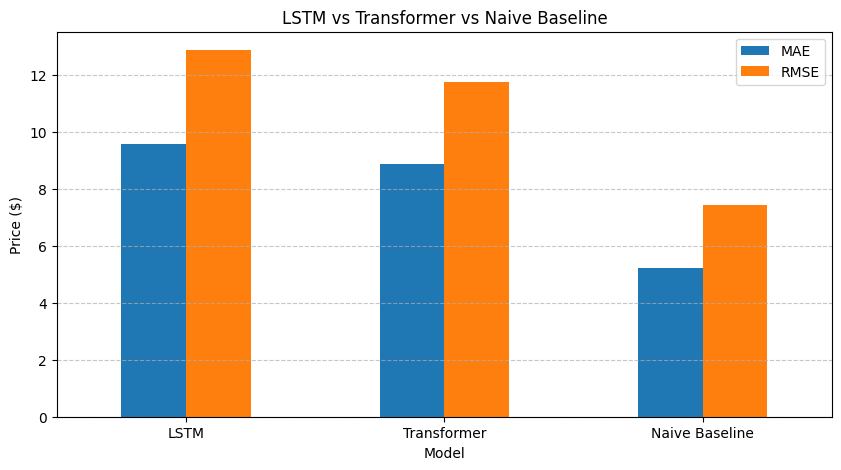

In [19]:
# Append to comparison DataFrame and plot
comparison_with_naive = pd.DataFrame([
    {
        "Model": "LSTM",
        "Parameters": count_params(lstm_model),
        "Training time (s)": lstm_train_time,
        **lstm_metrics
    },
    {
        "Model": "Transformer",
        "Parameters": count_params(transformer_model),
        "Training time (s)": transformer_train_time,
        **transformer_metrics
    },
    {
        "Model": "Naive Baseline",
        "Parameters": 0,
        "Training time (s)": 0.0,
        **naive_metrics
    }
])

display(comparison_with_naive)

ax = comparison_with_naive.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 5),
    rot=0
)
plt.title("LSTM vs Transformer vs Naive Baseline")
plt.ylabel("Price ($)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

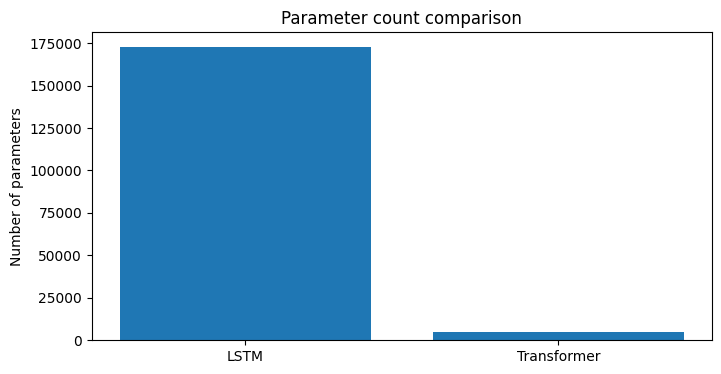

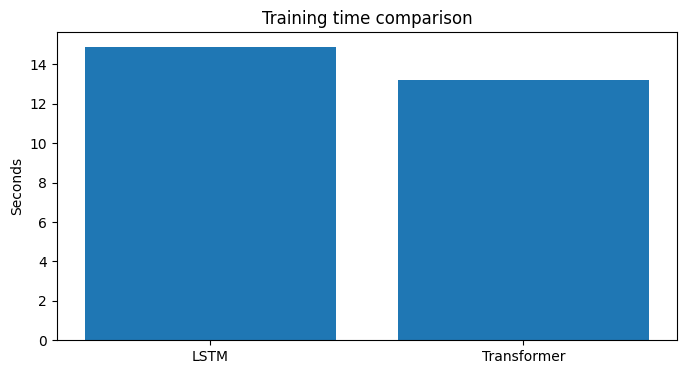

In [20]:
plt.figure(figsize=(8, 4))
plt.bar(comparison["Model"], comparison["Parameters"])
plt.title("Parameter count comparison")
plt.ylabel("Number of parameters")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(comparison["Model"], comparison["Training time (s)"])
plt.title("Training time comparison")
plt.ylabel("Seconds")
plt.show()

## 9. Visual comparison on the same test samples

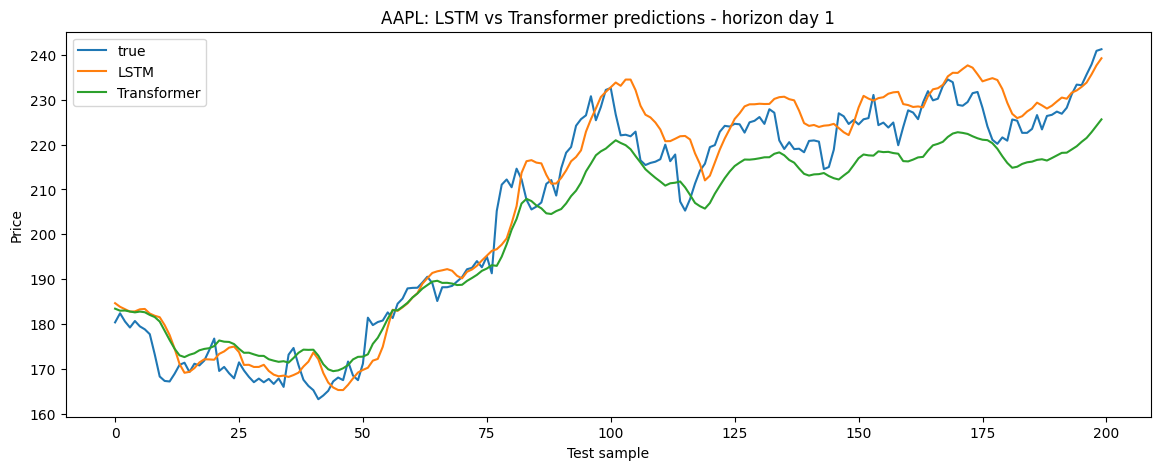

In [21]:
horizon_step = 0
max_points = 200

y_true = inverse_scale_targets(y_test, scaler)
lstm_pred_inv = inverse_scale_targets(lstm_pred, scaler)
transformer_pred_inv = inverse_scale_targets(transformer_pred, scaler)

n = min(max_points, len(y_true))

plt.figure(figsize=(14, 5))
plt.plot(y_true[:n, horizon_step], label="true")
plt.plot(lstm_pred_inv[:n, horizon_step], label="LSTM")
plt.plot(transformer_pred_inv[:n, horizon_step], label="Transformer")
plt.title(f"{TICKER}: LSTM vs Transformer predictions - horizon day {horizon_step + 1}")
plt.xlabel("Test sample")
plt.ylabel("Price")
plt.legend()
plt.show()

## 10. Predict the next future prices

This uses the most recent `LOOKBACK` prices to predict the next `HORIZON` prices.

In [22]:
last_window = scaler.transform(df[["price"]].values[-LOOKBACK:]).reshape(1, LOOKBACK, 1).astype("float32")
last_window_t = torch.tensor(last_window).to(device)

lstm_model.eval()
transformer_model.eval()
with torch.no_grad():
    next_lstm_scaled = lstm_model(last_window_t).cpu().numpy()
    next_transformer_scaled = transformer_model(last_window_t).cpu().numpy()

next_lstm = inverse_scale_targets(next_lstm_scaled, scaler).reshape(-1)
next_transformer = inverse_scale_targets(next_transformer_scaled, scaler).reshape(-1)

future_dates = pd.bdate_range(df.index[-1] + pd.Timedelta(days=1), periods=HORIZON)

future_df = pd.DataFrame({
    "date": future_dates,
    "LSTM prediction": next_lstm,
    "Transformer prediction": next_transformer
})

future_df

,date,LSTM prediction,Transformer prediction
0,2026-09-15,309.993225,288.215027
1,2026-09-16,313.047791,326.549561
2,2026-09-17,294.086700,317.545654
3,2026-09-18,292.653137,320.606598
4,2026-09-21,294.263916,329.966034


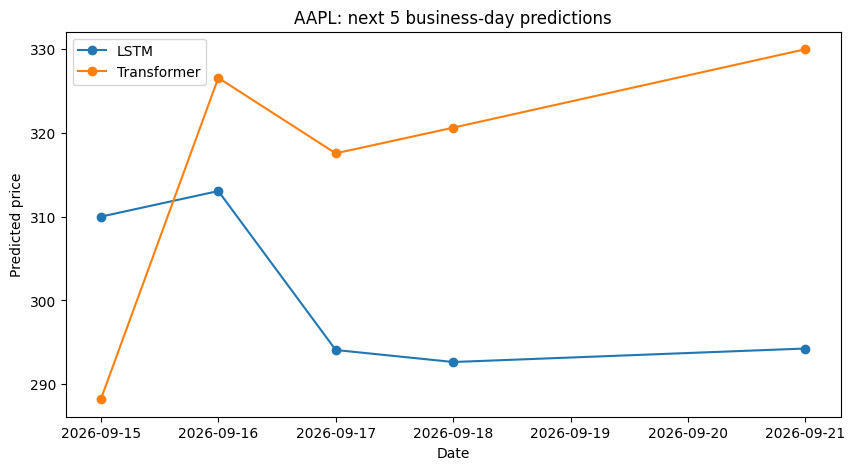

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(future_df["date"], future_df["LSTM prediction"], marker="o", label="LSTM")
plt.plot(future_df["date"], future_df["Transformer prediction"], marker="o", label="Transformer")
plt.title(f"{TICKER}: next {HORIZON} business-day predictions")
plt.xlabel("Date")
plt.ylabel("Predicted price")
plt.legend()
plt.show()

## 11. Interpretation guide

Typical points to discuss:

### LSTM

- Uses recurrence.
- Often works well on small time windows.
- Can be stable on simple time-series tasks.
- May have more parameters depending on hidden size.

### Transformer

- Uses self-attention instead of recurrence.
- Can learn relations between timesteps directly.
- Often scales well on large datasets.
- Can be less stable on small noisy financial datasets.

### Important

A lower MAPE in this notebook does **not** mean the model is suitable for trading.
For a serious financial model, you would need:

- walk-forward validation
- transaction costs
- risk-adjusted metrics
- comparison with simple baselines
- leakage checks
- multiple tickers and market regimes

## 12. Exercises for this Lab

1. Change `TICKER` to `MSFT`, `GOOGL`, `TSLA`, or an index ETF like `SPY`.
2. Increase `LOOKBACK` from 5 to 30 or 60.
3. Predict only one day ahead by setting `HORIZON = 1`.
4. Add more features: volume, returns, moving averages.
5. Compare against a naive baseline: "tomorrow = today".
6. Run each model multiple times and compare stability.
7. **PyTorch-specific:** replace the custom `MultiHeadSelfAttention` with PyTorch's built-in `nn.MultiheadAttention`, first adding a `nn.Linear(n_features, head_size * num_heads)` projection layer before it so the dimensions match. Does training behave differently?